# Digital Marketing Campaign Optimization with SQL, Predictive Analytics, and Interactive Dashboard



## Project Overview

This project analyzes digital marketing campaign performance across multiple customer segments and campaign channels using SQL, Python, and interactive dashboard visualization.

The objective is to identify the key drivers of customer conversion, evaluate campaign effectiveness, and generate actionable recommendations to optimize marketing strategy.



## Tools Used

- **SQL (Google BigQuery)** — campaign performance analysis and KPI aggregation
- **Python (Google Colab)** — data cleaning, exploratory analysis, feature engineering, and predictive modeling
- **Looker Studio** — interactive dashboard and business reporting



## Business Questions

This project focuses on answering several key business questions:

1. Which marketing channels perform best in driving customer conversions?
2. Which campaign types generate the strongest conversion outcomes?
3. Which customer segments are most likely to convert?
4. How does customer engagement impact conversion behavior?
5. Which variables are the strongest predictors of conversion?
6. What strategic recommendations can improve future campaign performance?


In [1]:
# =========================
# Import libraries
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.cluster import KMeans

# chart style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# Data Loading

The dataset used in this project contains customer demographics, campaign details, engagement metrics, and conversion outcomes.

This section loads the dataset and previews the first rows to validate the structure before starting the analysis.

---

In [2]:
# =========================
# Load dataset
# =========================

df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv")

# preview
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


# Data Overview and Initial Validation

Before starting the analysis, it is important to validate the dataset structure and check for possible data quality issues such as:

- incorrect data types
- missing values
- duplicate records
- unusual value distributions

This step helps ensure the dataset is ready for analysis and predictive modeling.

---

In [3]:
# =========================
# Dataset overview
# =========================

print("Shape of dataset:")
print(df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape of dataset:
(8000, 20)

Column data types:
CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

Missing values:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0


# Data Cleaning and Feature Engineering

After validating the dataset, the next step is preparing the data for analysis.

This includes:

- removing columns that are not useful for the analysis
- creating additional analytical features
- organizing customer segments for easier comparison

Feature engineering is important because it helps transform raw variables into more meaningful business metrics.

---

In [4]:
# =========================
# Drop unnecessary columns
# =========================

df = df.drop(
    columns=[
        "AdvertisingPlatform",
        "AdvertisingTool"
    ]
)

# =========================
# Engagement score
# =========================

df["engagement_score"] = (
    df["WebsiteVisits"]
    + df["PagesPerVisit"]
    + df["TimeOnSite"]
    + df["EmailClicks"]
)

# =========================
# Age group
# =========================

bins = [18, 25, 35, 45, 55, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55+"]

df["age_group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

# preview selected columns
df[
    [
        "Age",
        "age_group",
        "WebsiteVisits",
        "PagesPerVisit",
        "TimeOnSite",
        "EmailClicks",
        "engagement_score"
    ]
].head()

,Age,age_group,WebsiteVisits,PagesPerVisit,TimeOnSite,EmailClicks,engagement_score
0,56,55+,0,2.399017,7.396803,9,18.795819
1,69,55+,42,2.917138,5.352549,7,57.269686
2,46,45-54,2,8.223619,13.794901,2,26.018521
3,32,25-34,47,4.540939,14.688363,2,68.229302
4,60,55+,0,2.046847,13.993370,6,22.040218


# Exploratory Data Analysis

The first analysis compares conversion performance across campaign types.

This helps identify which campaign objective generates the strongest customer response and provides an early view of overall campaign effectiveness.

---

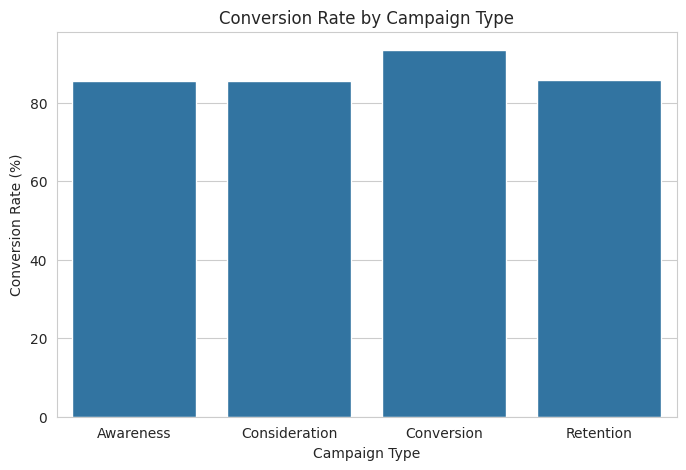

,CampaignType,Conversion,ConversionPercent
0,Awareness,0.855634,85.563380
1,Consideration,0.855634,85.563380
2,Conversion,0.933558,93.355802
3,Retention,0.858243,85.824345


In [5]:
# =========================
# Conversion by campaign type
# =========================

campaign_conversion = (
    df.groupby("CampaignType")["Conversion"]
    .mean()
    .reset_index()
)

campaign_conversion["ConversionPercent"] = (
    campaign_conversion["Conversion"] * 100
)

# chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=campaign_conversion,
    x="CampaignType",
    y="ConversionPercent"
)

plt.title("Conversion Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

campaign_conversion

The next analysis evaluates customer conversion across age groups.

Understanding age-based conversion patterns helps identify which customer segments are most responsive and where campaign targeting may be improved.

---

/tmp/ipykernel_4818/1544389396.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["Conversion"]


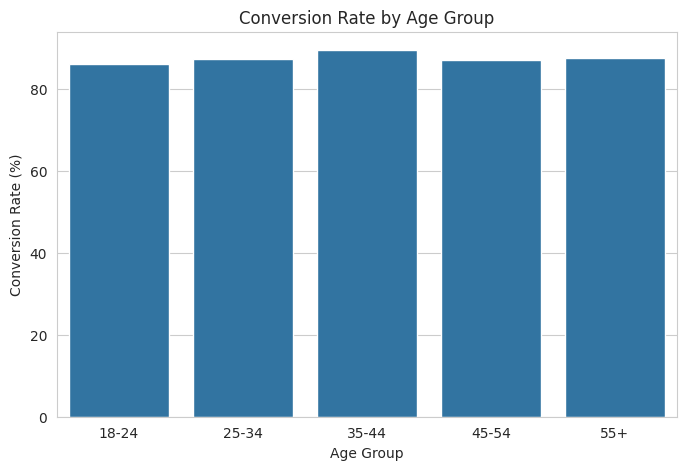

,age_group,Conversion,ConversionPercent
0,18-24,0.861300,86.129971
1,25-34,0.873120,87.311969
2,35-44,0.895899,89.589905
3,45-54,0.871009,87.100894
4,55+,0.875928,87.592835


In [6]:
# =========================
# Conversion by age group
# =========================

age_conversion = (
    df.groupby("age_group")["Conversion"]
    .mean()
    .reset_index()
)

age_conversion["ConversionPercent"] = (
    age_conversion["Conversion"] * 100
)

# chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_conversion,
    x="age_group",
    y="ConversionPercent"
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

age_conversion

Customer engagement is one of the most important indicators in digital marketing.

This analysis compares the engagement score between converted and non-converted customers to understand whether higher engagement is associated with stronger conversion performance.

---

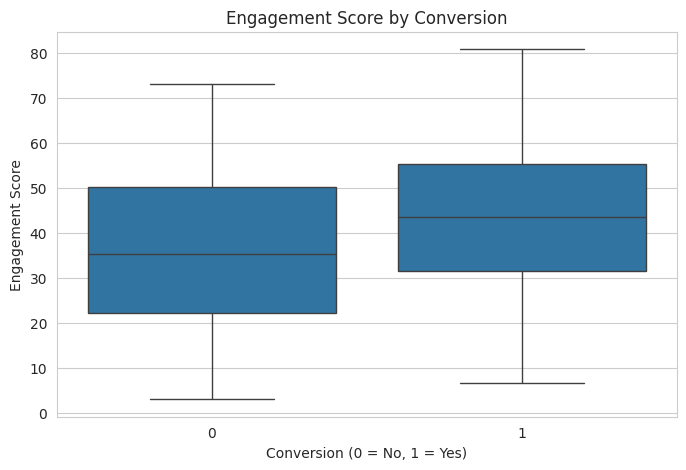

,engagement_score
Conversion,
0,36.311375
1,43.367442


In [7]:
# =========================
# Engagement score vs conversion
# =========================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Conversion",
    y="engagement_score"
)

plt.title("Engagement Score by Conversion")
plt.xlabel("Conversion (0 = No, 1 = Yes)")
plt.ylabel("Engagement Score")

plt.show()

# summary table
df.groupby("Conversion")["engagement_score"].mean()

The next analysis examines the correlation between numerical variables.

This helps identify which customer engagement and campaign variables are more closely associated with conversion and highlights patterns that support predictive modeling.

---

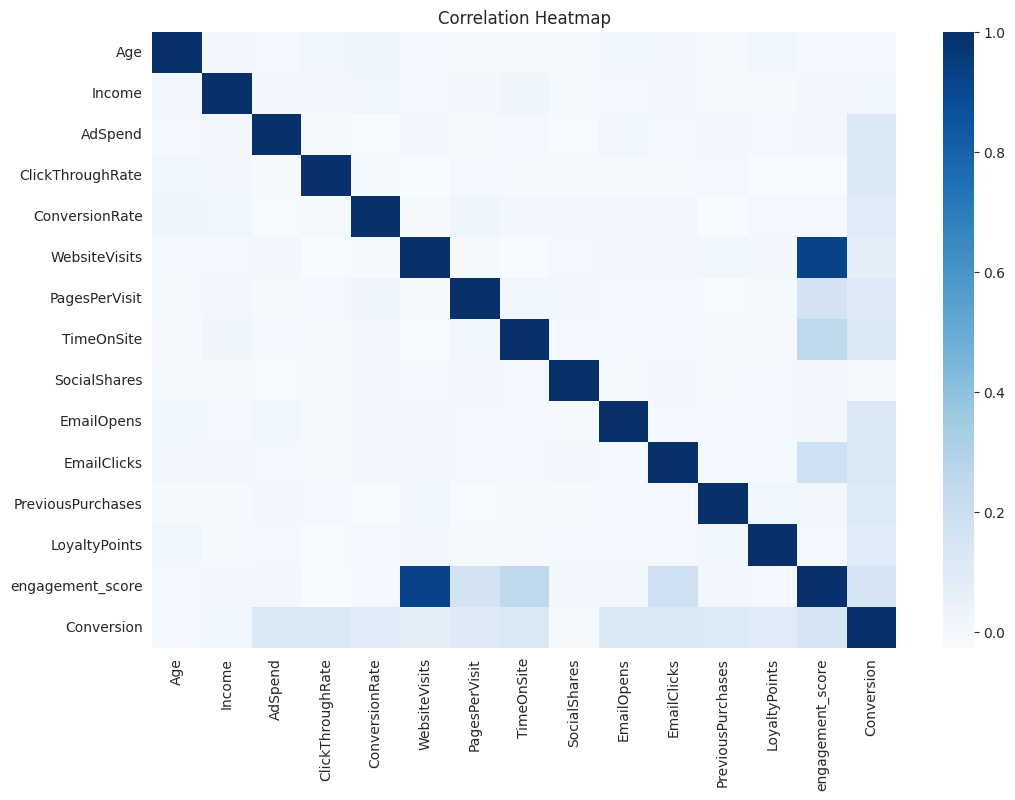

In [8]:
# =========================
# Correlation heatmap
# =========================

numeric_cols = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "ConversionRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints",
    "engagement_score",
    "Conversion"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="Blues",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

# Advanced Analysis


## A/B Testing Style Analysis

To validate whether campaign performance differences are statistically meaningful, a hypothesis test is performed between conversion-focused campaigns and all other campaign types.

This helps determine whether the higher conversion rate is likely due to actual performance differences rather than random variation.

---

In [22]:
# =========================
# A/B testing style analysis
# =========================

from scipy.stats import ttest_ind

# group A = conversion campaigns
group_a = df[
    df["CampaignType"] == "Conversion"
]["Conversion"]

# group B = all others
group_b = df[
    df["CampaignType"] != "Conversion"
]["Conversion"]

# t-test
t_stat, p_value = ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print("Conversion Campaign Avg:",
      round(group_a.mean()*100,2))

print("Other Campaign Avg:",
      round(group_b.mean()*100,2))

print("T-statistic:",
      round(t_stat,4))

print("P-value:",
      round(p_value,6))

Conversion Campaign Avg: 93.36
Other Campaign Avg: 85.65
T-statistic: 10.8304
P-value: 0.0


# Conversion Heatmap by Campaign Channel and Age Group

This heatmap compares conversion rates across campaign channels and customer age groups.

The goal is to identify which combinations perform best and where targeting opportunities may exist.

---

/tmp/ipykernel_4818/2297453912.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


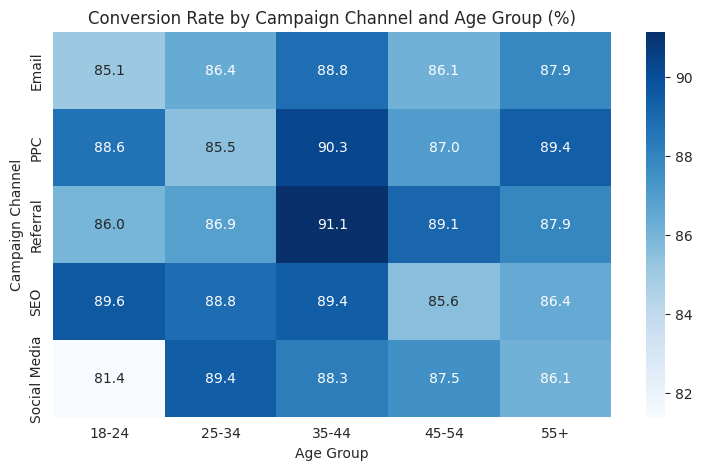

age_group,18-24,25-34,35-44,45-54,55+
CampaignChannel,,,,,
Email,85.096154,86.419753,88.778878,86.129032,87.864078
PPC,88.625592,85.538462,90.273556,87.043189,89.366053
Referral,85.972851,86.890244,91.131498,89.090909,87.914230
SEO,89.583333,88.848921,89.389068,85.573770,86.422414
Social Media,81.407035,89.416058,88.253968,87.500000,86.131387


In [21]:
# =========================
# Heatmap by channel + age
# =========================

heatmap_data = (
    df.groupby(
        ["CampaignChannel", "age_group"]
    )["Conversion"]
    .mean()
    .reset_index()
)

heatmap_data["ConversionPercent"] = (
    heatmap_data["Conversion"] * 100
)

pivot_table = (
    heatmap_data.pivot(
        index="CampaignChannel",
        columns="age_group",
        values="ConversionPercent"
    )
)

plt.figure(figsize=(9,5))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "Conversion Rate by Campaign Channel and Age Group (%)"
)

plt.xlabel("Age Group")
plt.ylabel("Campaign Channel")

plt.show()

pivot_table

# Predictive Modeling

After completing the exploratory analysis, the next step is building a predictive model.

The goal is to predict whether a customer will convert based on:

- customer profile
- campaign information
- engagement behavior

A Random Forest classifier is used because it performs well with mixed numerical and categorical data while also providing feature importance.

---

In [10]:
# =========================
# Encoding categorical variables
# =========================

df_encoded = df.copy()

cat_cols = [
    "Gender",
    "CampaignChannel",
    "CampaignType",
    "age_group"
]

for col in cat_cols:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(
        df_encoded[col].astype(str)
    )

# target
y = df_encoded["Conversion"]

# features
X = df_encoded.drop(
    columns=[
        "CustomerID",
        "Conversion"
    ]
)

print(X.shape)

(8000, 18)


In [11]:
# =========================
# Train test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (6400, 18)
Test : (1600, 18)


In [12]:
# =========================
# Random Forest model
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:,1]

print("Model training completed.")

Model training completed.


# Model Evaluation

After training the Random Forest classifier, the model is evaluated to measure prediction quality.

The evaluation focuses on:

- accuracy
- precision and recall
- confusion matrix
- ROC-AUC

These metrics help determine how well the model predicts customer conversion.

---

In [13]:
# =========================
# Accuracy + classification report
# =========================

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy, 4))
print()

print(classification_report(y_test, predictions))

Accuracy: 0.895

              precision    recall  f1-score   support

           0       0.82      0.17      0.28       194
           1       0.90      1.00      0.94      1406

    accuracy                           0.90      1600
   macro avg       0.86      0.58      0.61      1600
weighted avg       0.89      0.90      0.86      1600



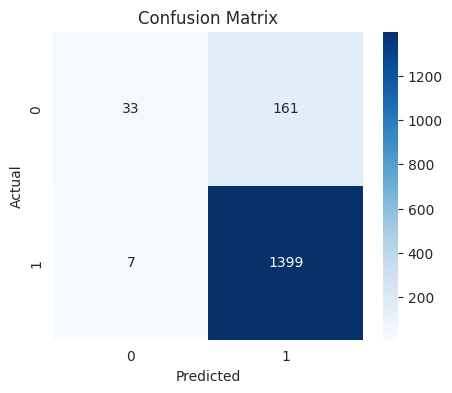

In [14]:
# =========================
# Confusion matrix
# =========================

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

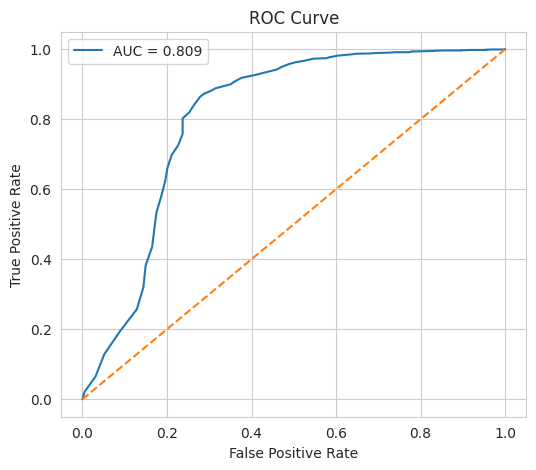

ROC AUC: 0.8085


In [15]:
# =========================
# ROC curve
# =========================

auc_score = roc_auc_score(
    y_test,
    probabilities
)

fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("ROC AUC:", round(auc_score,4))

# Feature Importance Analysis

To better understand what drives customer conversion, feature importance is analyzed using the Random Forest model.

This helps identify which variables contribute most strongly to prediction performance and supports strategic marketing recommendations.

---

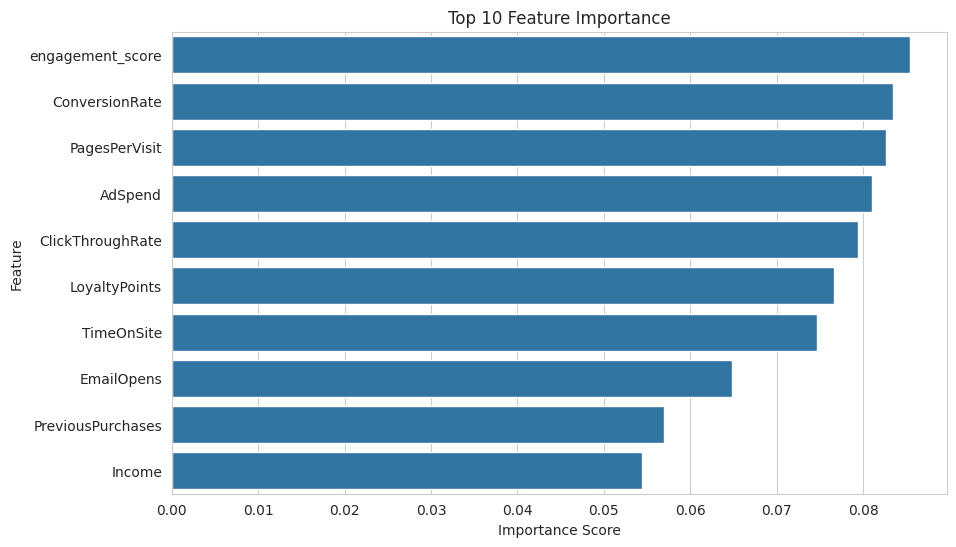

,Feature,Importance
16,engagement_score,0.085436
7,ConversionRate,0.083484
9,PagesPerVisit,0.082702
5,AdSpend,0.081018
6,ClickThroughRate,0.079424
15,LoyaltyPoints,0.076629
10,TimeOnSite,0.074723
12,EmailOpens,0.064872
14,PreviousPurchases,0.056945
2,Income,0.054470


In [16]:
# =========================
# Feature importance
# =========================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

# chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

importance.head(10)

# Customer Segmentation

To better understand customer behavior, clustering is used to group customers based on engagement and loyalty-related variables.

This helps identify customer segments with different marketing potential and supports more targeted campaign strategies.

---

In [17]:
# =========================
# Prepare clustering features
# =========================

cluster_features = df[
    [
        "engagement_score",
        "AdSpend",
        "LoyaltyPoints",
        "PreviousPurchases"
    ]
]

cluster_features.head()

,engagement_score,AdSpend,LoyaltyPoints,PreviousPurchases
0,18.795819,6497.870068,688,4
1,57.269686,3898.668606,3459,2
2,26.018521,1546.429596,2337,8
3,68.229302,539.525936,2463,0
4,22.040218,1678.043573,4345,8


In [18]:
# =========================
# KMeans clustering
# =========================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    cluster_features
)

df["Cluster"].value_counts()

,count
Cluster,
0,2746
1,2634
2,2620


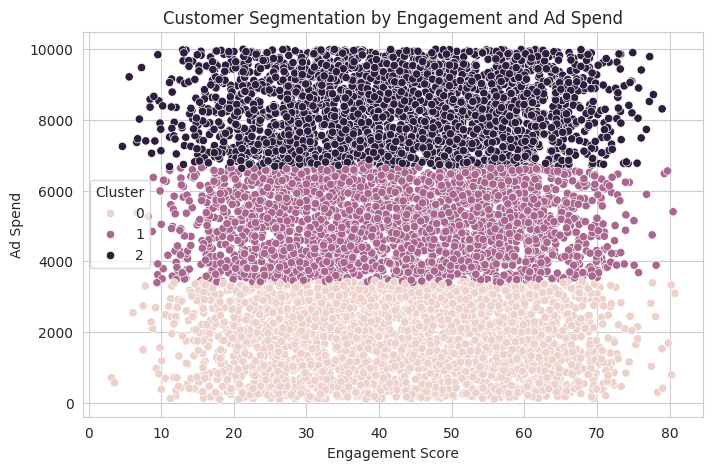

In [19]:
# =========================
# Cluster visualization
# =========================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="engagement_score",
    y="AdSpend",
    hue="Cluster"
)

plt.title("Customer Segmentation by Engagement and Ad Spend")
plt.xlabel("Engagement Score")
plt.ylabel("Ad Spend")

plt.show()

In [20]:
# =========================
# Cluster summary
# =========================

cluster_summary = (
    df.groupby("Cluster")[
        [
            "engagement_score",
            "AdSpend",
            "LoyaltyPoints",
            "PreviousPurchases",
            "Conversion"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,engagement_score,AdSpend,LoyaltyPoints,PreviousPurchases,Conversion
Cluster,,,,,
0,42.66,1783.27,2463.66,4.47,0.82
1,42.25,5067.91,2539.36,4.47,0.88
2,42.58,8306.04,2468.81,4.52,0.92


# Key Insights and Business Recommendations

## Project Summary

This project analyzed 8,000 customer records from a digital marketing campaign dataset using SQL (Google BigQuery), Python (Google Colab), and predictive analytics.

The objective was to evaluate campaign performance, understand customer conversion behavior, identify the most influential marketing factors, and generate actionable recommendations for digital marketing optimization.

The analysis combined exploratory data analysis, statistical validation, machine learning, and customer segmentation.

---

# 1. Campaign Performance Analysis

Campaign type showed clear performance differences.

Among all campaign objectives, **Conversion campaigns delivered the strongest performance**, reaching a conversion rate above 93%.

Awareness, Consideration, and Retention campaigns performed consistently, but remained below the Conversion campaign group.

## Key insight

Conversion-focused campaigns generated the highest conversion outcomes and consistently outperformed other campaign objectives.

## Business recommendation

When the goal is customer acquisition or direct conversion, campaign budget should prioritize conversion-focused campaign objectives.

---

# 2. Statistical Validation (A/B Testing Style Analysis)

To validate whether campaign performance differences were statistically meaningful, a hypothesis test was performed between Conversion campaigns and all other campaign types.

## Results

- Conversion campaign average: 93.36%
- Other campaign average: 85.65%
- T-statistic: 10.83
- P-value: < 0.001

## Key insight

The difference was statistically significant.

This confirms that Conversion campaigns performed better due to actual performance differences rather than random variation.

## Business recommendation

Marketing teams should prioritize conversion-oriented campaigns when performance efficiency is the primary objective.

---

# 3. Customer Demographics

Conversion rates varied slightly across age groups.

The **35–44 segment produced the highest conversion rate**, followed by 55+ and 25–34.

Customers aged 18–24 showed the lowest conversion performance.

Income groups showed only minor differences.

## Key insight

Mid-age customers responded most effectively to digital campaigns.

## Business recommendation

Targeting strategies can prioritize the 35–44 segment while improving personalization and messaging for younger customers.

---

# 4. Customer Engagement Behavior

Customer engagement showed one of the strongest relationships with conversion.

Converted customers consistently demonstrated:

- higher website visits
- more pages viewed
- longer time on site
- stronger email engagement

The engagement score distribution also showed a clear difference between converted and non-converted customers.

## Key insight

Higher engagement strongly increased conversion probability.

## Business recommendation

Campaign optimization should focus on:

- improving landing page experience
- increasing session depth
- strengthening email engagement
- improving on-site content relevance

---

# 5. Correlation Analysis

Correlation analysis confirmed that engagement-related variables had stronger relationships with conversion than demographic variables.

The strongest relationships appeared between:

- WebsiteVisits
- PagesPerVisit
- TimeOnSite
- EmailClicks
- engagement_score

Age and income showed weaker relationships.

## Key insight

Customer behavior metrics were more predictive than demographic attributes.

## Business recommendation

Behavioral metrics should become a stronger focus in campaign performance monitoring.

---

# 6. Channel + Age Group Heatmap

Heatmap analysis revealed meaningful differences between campaign channels and age groups.

Highest-performing combinations:

- Referral + 35–44 → 91.1%
- PPC + 35–44 → 90.3%

Lowest-performing combination:

- Social Media + 18–24 → 81.4%

SEO also performed consistently across multiple age groups.

## Key insight

Campaign performance varies significantly by channel and age combination.

## Business recommendation

Marketing budget should be optimized using more targeted channel allocation by customer segment.

---

# 7. Predictive Modeling

A Random Forest classifier was used to predict customer conversion.

## Model performance

- Accuracy: 89.5%
- ROC AUC: 0.809

The model performed well overall and successfully captured conversion behavior.

The dataset was highly imbalanced because most customers converted.

A balanced model was also tested, but did not improve overall performance.

## Key insight

The predictive model successfully identified conversion patterns and confirmed the importance of engagement metrics.

---

# 8. Feature Importance

Feature importance analysis identified the strongest conversion drivers.

Top features included:

- engagement_score
- ConversionRate
- PagesPerVisit
- AdSpend
- ClickThroughRate
- LoyaltyPoints
- TimeOnSite
- EmailOpens

## Key insight

Customer engagement was the strongest overall predictor of conversion.

## Business recommendation

Teams should track engagement-related KPIs as core campaign performance indicators.

---

# 9. Customer Segmentation

KMeans clustering grouped customers into three segments.

## Cluster 0 — Budget-Conscious Segment

- lowest ad spend
- lowest conversion

## Cluster 1 — Balanced Performance Segment

- moderate ad spend
- stable conversion

## Cluster 2 — High-Investment High-Conversion Segment

- highest ad spend
- strongest conversion

## Key insight

Higher investment was associated with stronger conversion performance.

## Business recommendation

Budget allocation can be optimized by prioritizing stronger-performing segments while improving lower-performing groups more strategically.

---

# Final Recommendations

Based on the analysis, several recommendations can be made:

## 1. Increase focus on conversion-oriented campaigns

These campaigns consistently delivered the highest conversion performance.

## 2. Prioritize customer engagement

Improve:

- website experience
- session depth
- email interaction

because these had the strongest relationship with conversion.

## 3. Target the 35–44 segment more aggressively

This group demonstrated the strongest campaign response.

## 4. Optimize channel strategy by age segment

Referral and PPC performed strongly for mid-age customers.

Social media may require stronger optimization for younger audiences.

## 5. Use predictive analytics for campaign planning

Behavioral engagement signals can support better conversion targeting.

## 6. Use customer segmentation to improve budget allocation

Different spending groups showed different conversion potential.

---

# Conclusion

This project demonstrates how SQL, Python, machine learning, and data visualization can be combined to evaluate digital marketing performance end-to-end.

The analysis showed that:

- campaign objective strongly impacts results
- conversion campaigns significantly outperform other campaign types
- customer engagement is the strongest conversion driver
- predictive modeling can identify conversion behavior
- segmentation supports smarter budget allocation
- channel strategy performs differently across age groups

These findings support more targeted, measurable, and data-driven marketing decisions.